This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment PASSIVE model to the multi-compartment one.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

Here we focus on why the u values systematically explode (during the course of a simulation) when the u_time_constant is lower. We found out that this behaviour is due to the initialization of the neural network, so we use a stability-informed initialization based on https://arxiv.org/pdf/2311.15890, and get stable u values.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib as mpl
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import math 


import equinox as eqx
import flax.nnx as nnx

In [33]:
t_max = 200.0
cut = 0

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"


# Define target
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)


all_setup = set_setup(setup)
cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])

simulate_multi = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_multi = simulate_multi()

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


In [34]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_passive_simulator,
    setup_passive_simulator_step,
    build_passive_cell,
    set_setup,
)

all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

simulate_single = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_single = simulate_single(x_o)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


**Initialization**

In [35]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    sample_eigenvalues_on_circle, # To test what happens when eigenvalues are on the boundary of the stability region
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices

)

In [36]:
key = jax.random.PRNGKey(0)
dt = 0.025

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   # RK4
    h=dt,
    u_dim=8,
    use_complex=True,
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, "scaled: ", dt*e)

Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) scaled:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) scaled:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) scaled:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) scaled:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) scaled:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) scaled:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) scaled:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) scaled:  (-0.9220778457683627+0.47510614586898203j)


In [37]:
# What if we sample eigenvalues ON the circle? Answer: nothing special
# eigs = sample_eigenvalues_on_circle(dt, 8)

# And what if we create eigenvalues with zero real parts? Answer: Nothing special
# imag_parts = np.random.uniform(-100, 100, size=4)

# Create complex array with zero real parts
# new_eigs = 0 + 1j * imag_parts
# eigs[-4:] = new_eigs
# print(eigs)

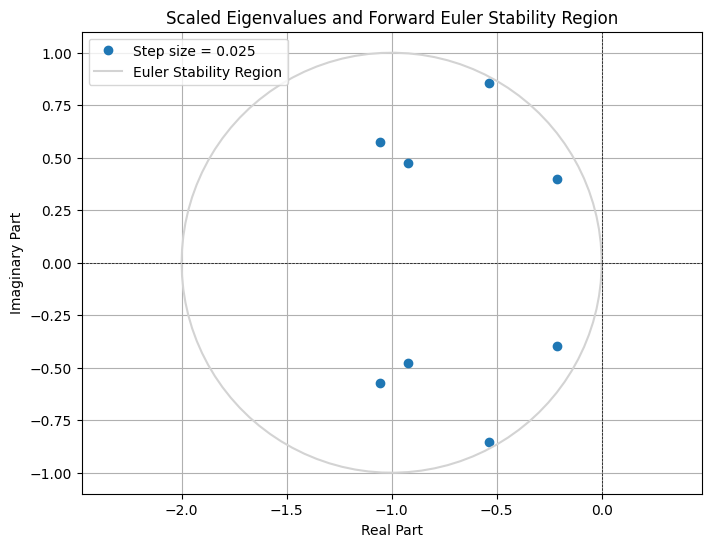

In [38]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

Now we make the Lambda, Pi and W matrices based on the paper

In [39]:
num_layers = 3
layer_shapes = [(9, 32), (32, 16), (16, 8)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

In [40]:
# Checking the eigenvalues of the generated initialization
jnp.linalg.eigvals(W_matrices[2]@W_matrices[1]@W_matrices[0][:, :8])

Array([-42.14161353+22.98417698j, -42.14161353-22.98417698j,
       -21.54550625+34.14736393j, -21.54550625-34.14736393j,
       -36.88311383+19.00424583j, -36.88311383-19.00424583j,
        -8.51603533+15.86861961j,  -8.51603533-15.86861961j],      dtype=complex128)

In [41]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_multi)) / (jnp.max(v_multi) - jnp.min(v_multi)) - 1
    

class SimpleNeuralNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, W_matrices: list[jax.Array], epsilon: float = 1e-4):
        self.linear1 = nnx.Linear(u_dimension + 1, 32, rngs=rngs)
        #self.norm1 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear2 = nnx.Linear(32, 16, rngs=rngs)
        #self.norm2 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear3 = nnx.Linear(16, u_dimension, rngs=rngs)

        # Stability-informed initialization
        # self.linear1.kernel = nnx.Param(W_matrices[0].T)
        # self.linear2.kernel = nnx.Param(W_matrices[1].T)
        # self.linear3.kernel= nnx.Param(W_matrices[2].T)

        # self.linear1.bias = nnx.Param(jax.random.uniform(rngs(), (32,), minval=-epsilon, maxval=epsilon))
        # self.linear2.bias = nnx.Param(jax.random.uniform(rngs(), (16,), minval=-epsilon, maxval=epsilon))
        # self.linear3.bias = nnx.Param(jax.random.uniform(rngs(), (u_dimension,), minval=-epsilon, maxval=epsilon))

    def __call__(self, inputs):
        x = self.linear1(inputs)
        x = jax.nn.relu(x)
        # x = 2* jax.nn.sigmoid(x) - 1
        # x = jax.nn.tanh(x)

        x = self.linear2(x)
        x = jax.nn.relu(x)
        # x = 2* jax.nn.sigmoid(x) - 1
        # x = jax.nn.tanh(x)
        return self.linear3(x)

class ReadoutNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8):
        self.linear1 = nnx.Linear(u_dimension, 32, rngs=rngs)
        self.linear2 = nnx.Linear(32, 1, rngs=rngs)

    def __call__(self, u):
        u = self.linear1(u)
        u = jax.nn.relu(u)
        return self.linear2(u)
    
class CorrectionModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, W_matrices: list[jax.Array], epsilon: float = 1e-4):
        self.neural_net = SimpleNeuralNet(rngs=rngs, u_dimension = u_dimension, W_matrices=W_matrices, epsilon = epsilon)
        self.readout_net = ReadoutNet(rngs=rngs, u_dimension = u_dimension)

    def __call__(self, u, v):
        u_new = self.neural_net(jnp.stack([u, v]))
        return self.readout_net(u_new)

In [42]:
dt = 0.025

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, added_curr_std, u_time_constant):
    def cond_fn(carry):
        t, _, _, _ = carry
        return t < len(time_vec)

    def body_fn(carry):
        t, state, u, recs_adds = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)
        

        u_new = u + dt*neural_net(inputs) / u_time_constant #0.02 #0.0008
        add_current = readout_net(u_new).squeeze()
        nn_res = neural_net(inputs)

        # RK4 method
        # def f(u_local):
        #     inputs = jnp.concatenate([u_local, jnp.expand_dims(voltage_normalized, 0)], axis=0)
        #     return neural_net(inputs) / u_time_constant

        # k1 = f(u)
        # k2 = f(u + 0.5 * dt * k1)
        # k3 = f(u + 0.5 * dt * k2)
        # k4 = f(u + dt * k3)

        # u_new = u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        # add_current = readout_net(u_new).squeeze()



        total_current = current[t] + add_current * added_curr_std #/300 #10
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]

        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(nn_res)

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses))

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses))

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses) = final_carry

    return recs, adds, us, nn_reses

In [43]:
def loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant, reg_strength=0.0):
    
    preds, additional_currents, us, nn_reses = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, added_curr_std, u_time_constant
    )

    preds = preds.squeeze()
    v_multi = v_multi.squeeze()

    sse_loss = jnp.sum((preds - v_multi) ** 2)
    reg_loss = reg_strength * jnp.sum(jnp.abs(additional_currents))

    total_loss = sse_loss + reg_loss
    return total_loss

In [44]:
rngs = nnx.Rngs(1)

u_dimension = 8
np.random.seed(42)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4
model = CorrectionModel(rngs = rngs, u_dimension = u_dimension,  W_matrices = W_matrices, epsilon = epsilon)

t_max = 200

# Setup simulator
all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
initial_state, step_fn, current, time_vec = setup_passive_simulator_step(cell, t_max, all_setup["v_init"], i_amp)

added_curr_std = 1.0/150.0
u_time_constant = 1000


initial_lr = 12e-3  #2e-1 for lbfgs?
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400 # after x epochs, stop decaying
decay_start = 200
decay_end = 750

# Normal exponential decay schedule
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

# Wrapped schedule that stops decaying after decay_until
# def clipped_schedule(step):
#     clipped_step = jnp.minimum(step, decay_until)
#     return raw_schedule(clipped_step)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

optimizer = optax.adam(learning_rate=custom_schedule)

# Other optimizers tried:
# optimizer = optax.sgd(learning_rate=clipped_schedule, momentum = 0.7)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1e6),  # Clip gradients
#     optax.sgd(learning_rate=clipped_schedule, momentum=0.5)
# )

# optimizer = optax.chain(
#     optax.scale_by_lbfgs(memory_size = 8), #6
#     optax.scale(-initial_lr),
# )

optimizer_state = nnx.Optimizer(model, optimizer)


def simulation_loss_fn(model):
        loss = loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant)
        return loss


num_epochs = 400
losses = []

grad_fn = nnx.jit(nnx.value_and_grad(simulation_loss_fn))

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [45]:
for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    loss, grads = grad_fn(optimizer_state.model)
    optimizer_state.update(grads)


    # inter_ts, inter_us, inter_preds, inter_additional_currents = simulate_full_trace(
    # model.neural_net,
    # model.readout_net,
    # initial_state,
    # step_fn,
    # current,
    # time_vec,
    # u_init
    # )
    

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
        # print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")
        # print(f"Min u: {jnp.min(inter_us)}, max u: {jnp.max(inter_us)}")
        # print(f"Min tnn: {jnp.min(inter_ts)}, max tnn: {jnp.max(inter_ts)}")
        # print("")

Epoch 0, Loss: 1325.746828
Epoch 10, Loss: 1192.707773
Epoch 20, Loss: 1076.903381
Epoch 30, Loss: 978.370302
Epoch 40, Loss: 921.028455
Epoch 50, Loss: 873.334056
Epoch 60, Loss: 860.375727
Epoch 70, Loss: 842.194922
Epoch 80, Loss: 823.925966
Epoch 90, Loss: 795.273223
Epoch 100, Loss: 761.363730
Epoch 110, Loss: 726.701961
Epoch 120, Loss: 672.814209
Epoch 130, Loss: 582.496017
Epoch 140, Loss: 546.916455
Epoch 150, Loss: 491.253553
Epoch 160, Loss: 411.323363
Epoch 170, Loss: 409.796069
Epoch 180, Loss: 352.245698
Epoch 190, Loss: 365.621327
Epoch 200, Loss: 334.030636
Epoch 210, Loss: 320.923214
Epoch 220, Loss: 301.835985
Epoch 230, Loss: 291.397079
Epoch 240, Loss: 278.208903
Epoch 250, Loss: 267.362684
Epoch 260, Loss: 257.421311
Epoch 270, Loss: 248.206092
Epoch 280, Loss: 280.199867
Epoch 290, Loss: 245.188868
Epoch 300, Loss: 229.388803
Epoch 310, Loss: 224.935791
Epoch 320, Loss: 218.857765
Epoch 330, Loss: 214.366660
Epoch 340, Loss: 210.219046
Epoch 350, Loss: 206.652200


In [46]:
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init,
    added_curr_std,
    u_time_constant
)


#final_sse_loss = jnp.sum((final_preds.squeeze() - v_multi.squeeze())**2)
#final_reg_loss = jnp.sum(final_additional_currents)

Text(0.5, 1.0, 'Hidden state (u) dynamics')

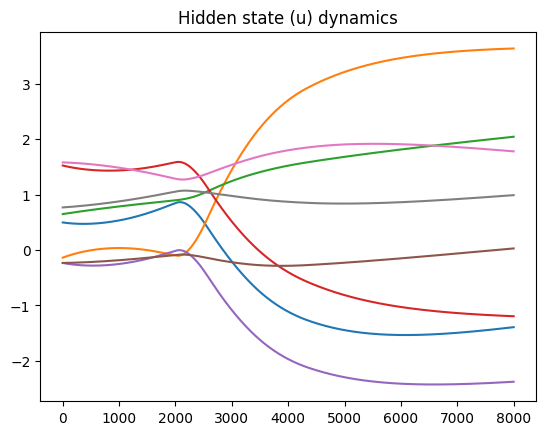

In [17]:
plt.plot(final_us)
plt.title("Hidden state (u) dynamics")

Text(0.5, 1.0, 'Dynamics network output')

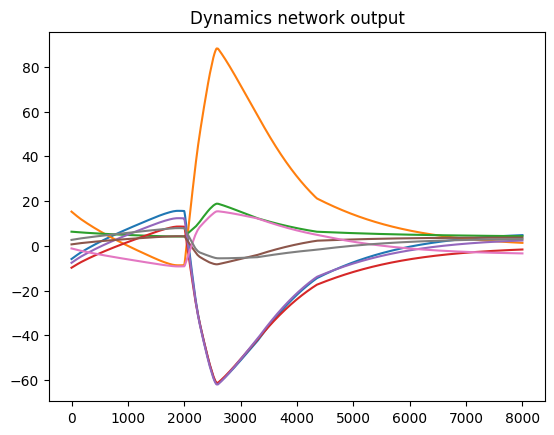

In [20]:
plt.plot(final_nn_reses)
plt.title("Dynamics network output")

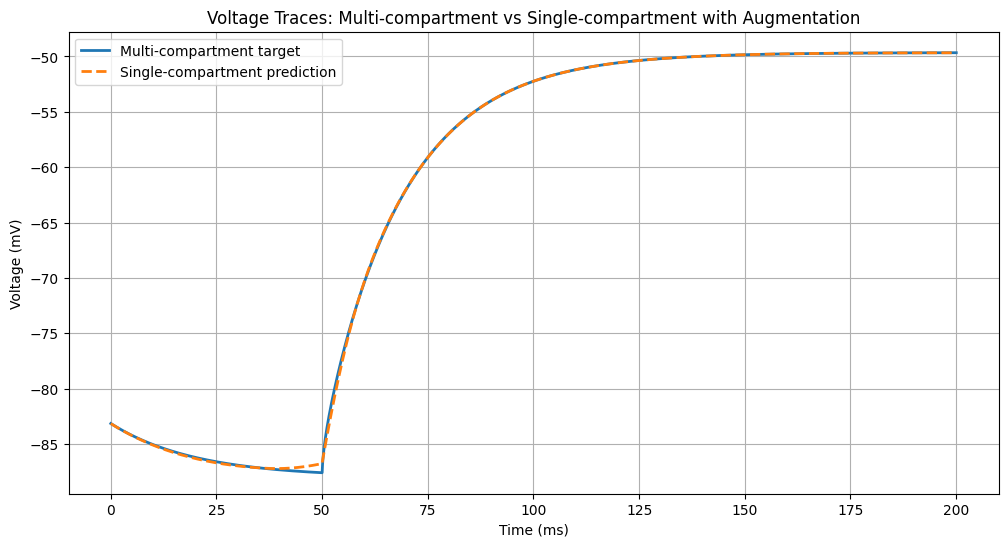

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec, v_multi[0], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

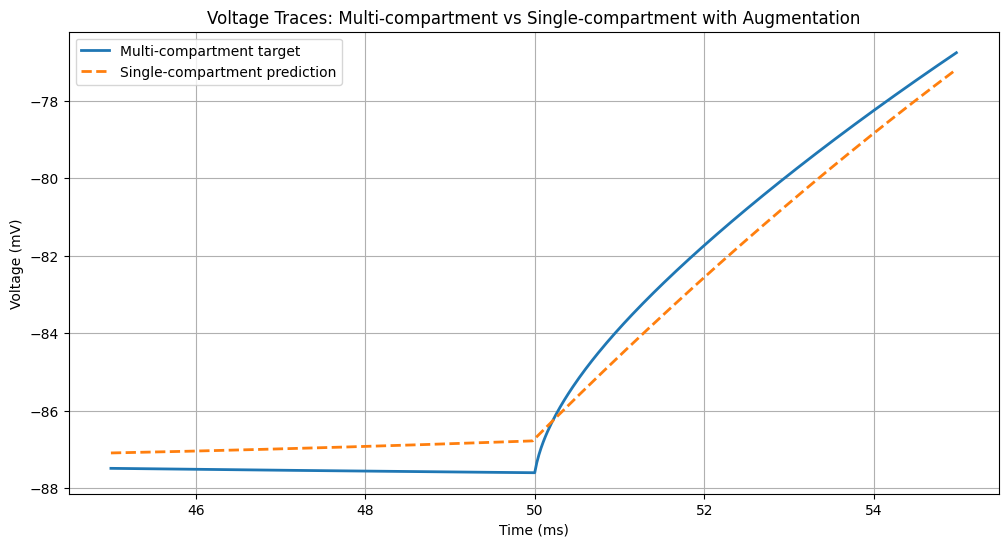

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec[1800:2200], v_multi[0][1800:2200], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec[1800:2200], final_preds[1800:2200], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

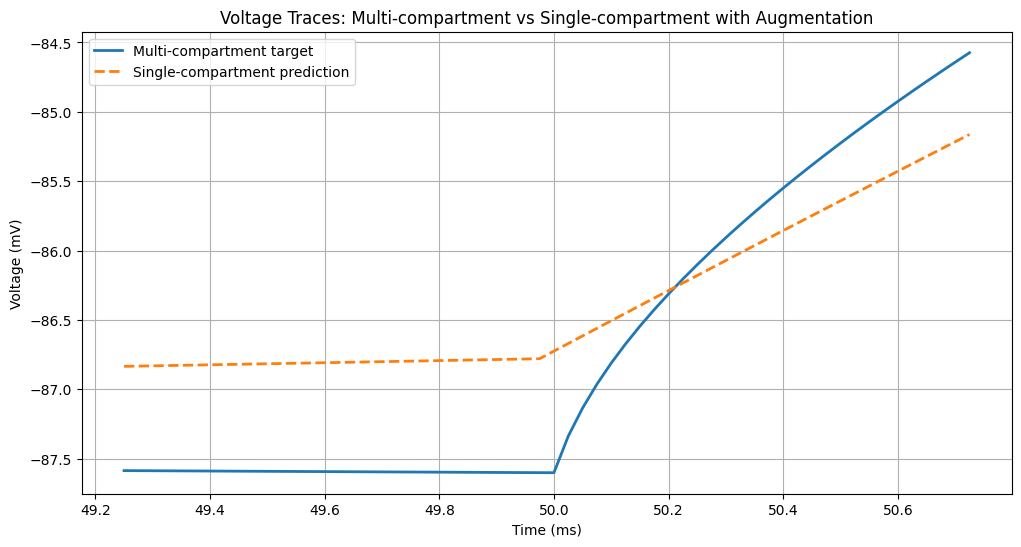

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(time_vec[1970:2030], v_multi[0][1970:2030], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec[1970:2030], final_preds[1970:2030], label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Voltage Traces: Multi-compartment vs Single-compartment with Augmentation")
plt.grid()

plt.show()

With the first activation being sigmoid - before training:

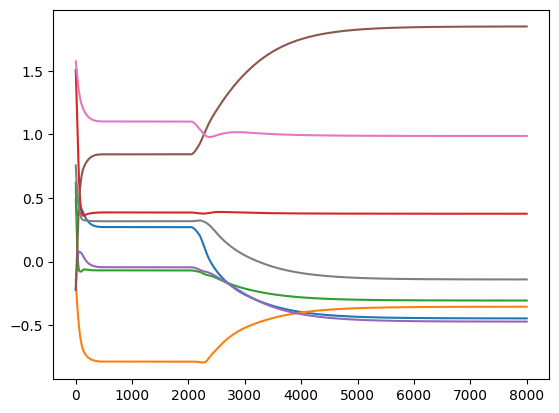

In [703]:
plt.plot(final_us)

After training - trains quite well:

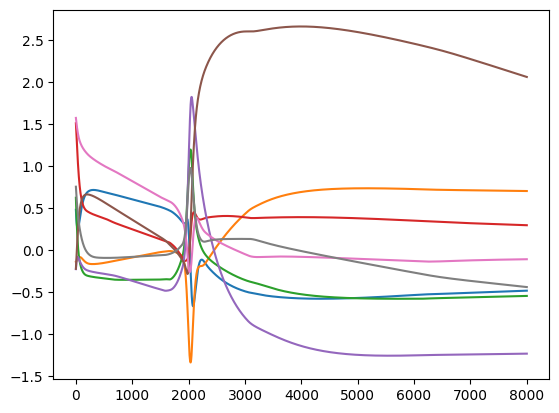

In [698]:
plt.plot(final_us)

Using Na() and K() channels

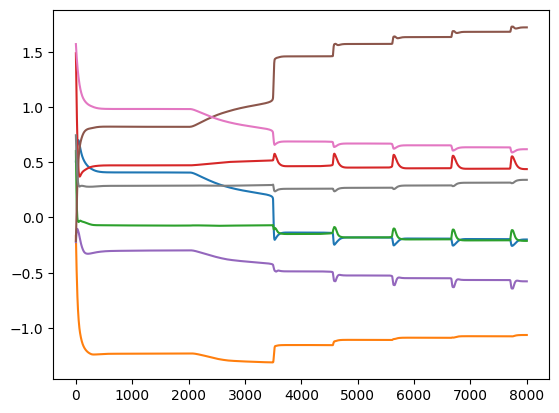

In [659]:
plt.plot(final_us)

How does the u value evolve during simulation with different time_constants?

Before training:

In [ ]:
# Don't use the initialization
u_constants = [1,5,10,100]
final_us_per_constant = []
for u_constant in u_constants:
    _, _, final_us, _ = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init,
    added_curr_std,
    u_constant
)
    final_us_per_constant.append(final_us)


In [ ]:
# Change the activation function to sigmoid
u_constants = [1,5,10,100]
final_us_per_constant_sigmoid = []
for u_constant in u_constants:
    _, _, final_us, _ = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init,
    added_curr_std,
    u_constant
)
    final_us_per_constant_sigmoid.append(final_us)


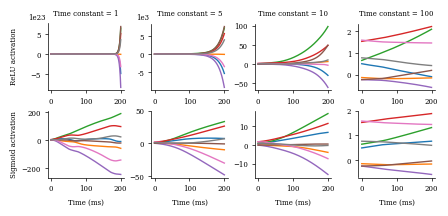

In [49]:
import matplotlib.ticker as mticker
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,4, figsize = (5,2))
    fig.subplots_adjust(wspace=0.35, hspace=0.3)

    axs[0,0].plot(time_vec, final_us_per_constant[0])
    axs[0,0].set_title("Time constant = 1", fontsize = 5)
    axs[0,0].yaxis.get_offset_text().set_position((-0.25, 0))   # (x, y) in axis coords
    axs[0,0].yaxis.get_offset_text().set_fontsize(5)
    #ax.yaxis.get_offset_text().set_horizontalalignment('right')
    axs[0,1].plot(time_vec, final_us_per_constant[1])
    axs[0,1].set_yticks([-5000, 0, 5000])
    axs[0,1].set_yticklabels([-5, 0, 5])

    fig.text(0.315, 0.90, "1e3", fontsize=5, ha="center")

    axs[0,1].yaxis.get_offset_text().set_text('1e3')
    axs[0,1].yaxis.get_offset_text().set_position((-0.25, 0))  # adjust position
    axs[0,1].yaxis.get_offset_text().set_fontsize(5)          # optional

    axs[0,1].set_title("Time constant = 5", fontsize = 5)
    axs[0,2].plot(time_vec, final_us_per_constant[2])
    axs[0,2].set_title("Time constant = 10", fontsize = 5)
    axs[0,3].plot(time_vec, final_us_per_constant[3])
    axs[0,3].set_yticks([0, 1, 2])
    axs[0,3].set_title("Time constant = 100", fontsize = 5)

    axs[1,0].plot(time_vec, final_us_per_constant_sigmoid[0])
    axs[1,0].set_xlabel("Time (ms)", fontsize = 5)
    axs[1,1].plot(time_vec, final_us_per_constant_sigmoid[1])
    axs[1,1].set_xlabel("Time (ms)", fontsize = 5)
    axs[1,1].set_yticks([-50, 0, 50])
    axs[1,2].plot(time_vec, final_us_per_constant_sigmoid[2])
    axs[1,2].set_xlabel("Time (ms)", fontsize = 5)
    axs[1,3].plot(time_vec, final_us_per_constant_sigmoid[3])
    axs[1,3].set_xlabel("Time (ms)", fontsize = 5)

    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=5)

    fig.text(0.05, 0.72, "ReLU activation", va="center", rotation="vertical", fontsize = 5)
    fig.text(0.05, 0.28, "Sigmoid activation", va="center", rotation="vertical", fontsize = 5)

    for ax in axs.flat:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)   # default is 1.0
        ax.tick_params(width=0.5)   

    fig.savefig("../svg/explosion.svg", bbox_inches='tight', dpi=300)


In [74]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("10.6cm", "5cm",
           
    Panel(
          SVG("../svg/explosion.svg").scale(svg_scale),
    ).move(0, 0),


)

#!mkdir -p fig
f.save("../fig/explosion.svg")
svg("../fig/explosion.svg")

In [ ]:
# Using the stability-informed initialization
u_constants = [1,10,100,1000]
final_us_per_constant_initialized = []
for u_constant in u_constants:
    _, _, final_us, _ = simulate_full_trace(
    model.neural_net,
    model.readout_net,
    initial_state,
    step_fn,
    current,
    time_vec,
    u_init,
    added_curr_std,
    u_constant
)
    final_us_per_constant_initialized.append(final_us)


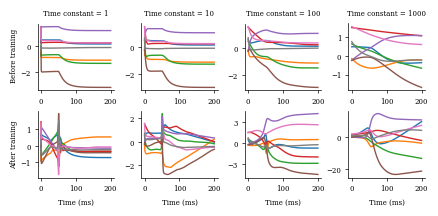

In [68]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,4, figsize = (5,2))
    fig.subplots_adjust(wspace=0.35, hspace=0.3)

    axs[0,0].plot(time_vec, final_us_per_constant_initialized[0])
    axs[0,0].set_title("Time constant = 1", fontsize = 5)
    #ax.yaxis.get_offset_text().set_horizontalalignment('right')
    axs[0,1].plot(time_vec, final_us_per_constant_initialized[1])
    axs[0,1].set_title("Time constant = 10", fontsize = 5)
    axs[0,2].plot(time_vec, final_us_per_constant_initialized[2])
    axs[0,2].set_title("Time constant = 100", fontsize = 5)
    axs[0,3].plot(time_vec, final_us_per_constant_initialized[3])
    axs[0,3].set_title("Time constant = 1000", fontsize = 5)

    axs[1,0].plot(time_vec, final_us_1)
    axs[1,0].set_xlabel("Time (ms)", fontsize = 5)
    axs[1,0].set_yticks([-1,0,1])
    axs[1,1].plot(time_vec, final_us_10)
    axs[1,1].set_xlabel("Time (ms)", fontsize = 5)
    axs[1,1].set_yticks([-2,0,2])
    axs[1,2].plot(time_vec, final_us_100)
    axs[1,2].set_xlabel("Time (ms)", fontsize = 5)
    axs[1,2].set_yticks([-3,0,3])
    axs[1,3].plot(time_vec, final_us_1000)
    axs[1,3].set_xlabel("Time (ms)", fontsize = 5)

    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)   # default is 1.0
        ax.tick_params(width=0.5)  

    fig.text(0.07, 0.72, "Before training", va="center", rotation="vertical", fontsize = 5)
    fig.text(0.07, 0.28, "After training", va="center", rotation="vertical", fontsize = 5)

    fig.savefig("../svg/explosion_initialized.svg", bbox_inches='tight', dpi=300)


In [72]:
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("10.4cm", "5cm",
           
    Panel(
          SVG("../svg/explosion_initialized.svg").scale(svg_scale),
    ).move(0, 0),


)

#!mkdir -p fig
f.save("../fig/explosion_initialized.svg")
svg("../fig/explosion_initialized.svg")

Why is no special initialization causes exponentially exploding u_values?

In [ ]:
# Comment out the initialization in the model!

voltage = -0.88
v_norm = normalize_voltage(voltage) 


# Define function to get u_next from u
def u_update_fn(u):
    new_inputs = jnp.concatenate([u, jnp.expand_dims(v_norm, 0)], axis=0)
    return model.neural_net(new_inputs)

# Compute Jacobian: shape should be (8, 8)
jacobian_fn = jax.jacrev(u_update_fn)
jacobian_matrix = jacobian_fn(jnp.zeros((8,)))


eigenvalues = jnp.linalg.eigvals(jacobian_matrix)

print("Jacobian matrix:")
print(jacobian_matrix)
print("Eigenvalues:")
print(eigenvalues)

Jacobian matrix:
[[-0.13436518  0.2188964  -0.10384743 -0.23953985  0.14004495 -0.41113982
   0.36823996 -0.25240026]
 [-0.05943244  0.09575719  0.00697161 -0.21068435 -0.10360401  0.15128445
   0.11795023 -0.01471549]
 [ 0.29519118 -0.14834336  0.10065479  0.24694422 -0.07269922 -0.65230251
   0.13726504 -0.16317218]
 [-0.09605537 -0.04945203  0.2448415   0.01238224 -0.15184449  0.39183439
  -0.33473079  0.07312777]
 [-0.23748348  0.15584671 -0.11820865 -0.17730691 -0.00318163  0.09422414
   0.18004991 -0.05365705]
 [-0.03647031 -0.21717865 -0.18672868 -0.08714776 -0.14194436  0.13942103
   0.29094448  0.28223212]
 [ 0.02041341  0.56748833 -0.19810425 -0.07796424 -0.20155088 -0.27101939
   0.06419444 -0.15207853]
 [-0.04439201 -0.23912544  0.1662689  -0.08484658  0.42918896 -0.19158591
   0.01205862  0.01405353]]
Eigenvalues:
[ 0.4900761 +0.j          0.35475119+0.j         -0.00274863+0.41952442j
 -0.00274863-0.41952442j -0.20948191+0.28649808j -0.20948191-0.28649808j
 -0.16517892+0.

In [17]:
h = 0.025 # step size

# Compute and print whether each eigenvalue satisfies the condition
stable = jnp.abs(1 + h * eigenvalues) <= 1
for i, (eig, is_stable) in enumerate(zip(eigenvalues, stable)):
    print(f"Eigenvalue {i+1}: {eig:.6f}, |1 + h*eig| = {jnp.abs(1 + h * eig):.6f}, Stable: {is_stable}")

Eigenvalue 1: 0.490076+0.000000j, |1 + h*eig| = 1.012252, Stable: False
Eigenvalue 2: 0.354751+0.000000j, |1 + h*eig| = 1.008869, Stable: False
Eigenvalue 3: -0.002749+0.419524j, |1 + h*eig| = 0.999986, Stable: True
Eigenvalue 4: -0.002749-0.419524j, |1 + h*eig| = 0.999986, Stable: True
Eigenvalue 5: -0.209482+0.286498j, |1 + h*eig| = 0.994789, Stable: True
Eigenvalue 6: -0.209482-0.286498j, |1 + h*eig| = 0.994789, Stable: True
Eigenvalue 7: -0.165179+0.000000j, |1 + h*eig| = 0.995871, Stable: True
Eigenvalue 8: 0.033729+0.000000j, |1 + h*eig| = 1.000843, Stable: False


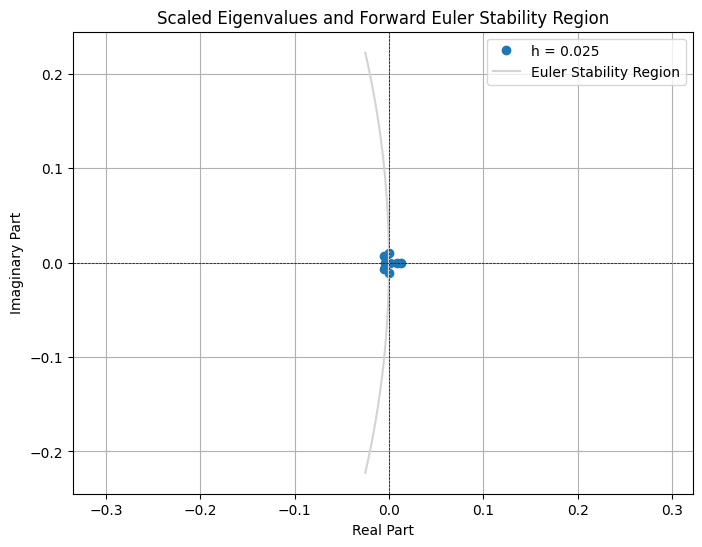

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = h * eigenvalues
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"h = {h}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi/14, np.pi/14, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

Is this a general problem?

With torch, using ReLU it is. Sigmoid gives linear divergence.

In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint

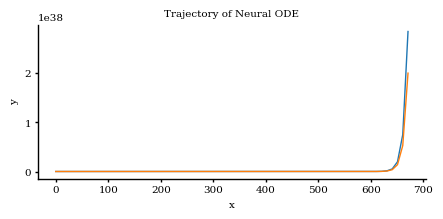

In [3]:
class ODEFunc(nn.Module):
    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),   # Input dimension is 2, hidden layer size is 50
            nn.ReLU(),          # Activation function (ReLU/Sigmoid)
            nn.Linear(50, 2)    # Output dimension is 2
        )

    def forward(self, t, y):
        return self.net(y)  # Forward pass: returns the time derivative of the state
    
def solve_ode(func):                       
    y0 = torch.tensor([[0.0, 1.0]])           # Initial hidden state (2D vector)
    t = torch.linspace(0, 10000, 1000)            # Time points to evaluate the solution
    y = odeint(func, y0, t, method = 'euler')                   # Solve the ODE
    
    
    return t, y


seed = 23 #18 - converges, but one eig is not in the circle, 23: - one eig in, but diverges, 25 same #Sigmoid: 7
np.random.seed(seed)
torch.manual_seed(seed)
func = ODEFunc()

def plot_trajectory():
    t, y = solve_ode(func)                       
    plt.plot(t, y[:, 0, 0].detach().numpy())  
    plt.plot(t, y[:, 0, 1].detach().numpy())
    plt.title('Trajectory of Neural ODE')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

t, y = solve_ode(func) 
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,1, figsize=(5,2))
    axs.plot(t, y[:, 0, 0].detach().numpy()) 
    axs.plot(t, y[:, 0, 1].detach().numpy())
    axs.set_title('Trajectory of Neural ODE')
    axs.set_xlabel('x')
    axs.set_ylabel('y')

In [26]:
from torch.autograd.functional import jacobian

y0 = torch.tensor([0.25, -0.25], requires_grad=True)

# Define a wrapper function: accepts y and returns func(t, y)
def func_y_only(y):
    return func(0, y)  # fix t=0

# Compute Jacobian (2x2 matrix)
jac = jacobian(func_y_only, y0)

print("Jacobian matrix at y0:")
print(jac)

eigvals = torch.linalg.eigvals(jac)
print("Eigenvalues of the Jacobian:")
print(eigvals)

Jacobian matrix at y0:
tensor([[-0.0578,  0.0763],
        [ 0.0099, -0.0094]])
Eigenvalues of the Jacobian:
tensor([-0.0702+0.j,  0.0029+0.j])


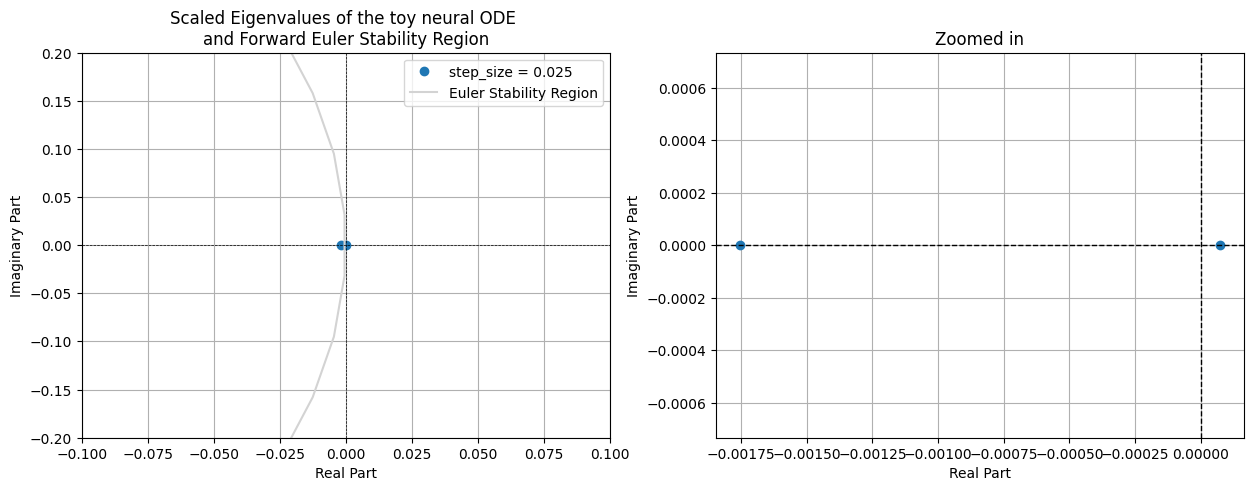

In [31]:
fig, axs = plt.subplots(1,2, figsize=(15, 5))

# Plot scaled eigenvalues for each h
scaled_eigs_torch = 0.025*eigvals
axs[0].plot(scaled_eigs_torch.real, scaled_eigs_torch.imag, 'o', label=f"step_size = {0.025}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
axs[0].plot(x, y, color='lightgrey', label='Euler Stability Region')

axs[0].set_xlim(-0.1, 0.1)
axs[0].set_ylim(-0.2, 0.2)

axs[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axs[0].axvline(0, color='black', linestyle='--', linewidth=0.5)
axs[0].set_title("Scaled Eigenvalues of the toy neural ODE \nand Forward Euler Stability Region")
axs[0].set_xlabel("Real Part")
axs[0].set_ylabel("Imaginary Part")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(scaled_eigs_torch.real, scaled_eigs_torch.imag, 'o', label=f"step_size = {0.025}")
axs[1].axhline(0, color='black', linestyle='--', linewidth=1)
axs[1].axvline(0, color='black', linestyle='--', linewidth=1)
axs[1].set_title("Zoomed in")
axs[1].set_xlabel("Real Part")
axs[1].set_ylabel("Imaginary Part")
axs[1].grid(True)
plt.axis('equal')
plt.show()

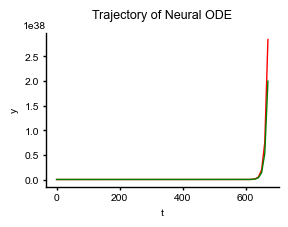

In [6]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    t, y = solve_ode(func) 
    fig, ax = plt.subplots(1,1, figsize=(3,2))
    fig.subplots_adjust(wspace=0.3)
    ax.plot(t, y[:, 0, 0].detach().numpy(), c='r') 
    ax.plot(t, y[:, 0, 1].detach().numpy(), c='g')
    ax.yaxis.get_offset_text().set_position((-0.1, 0))   # (x, y) in axis coords
    #axs[0].yaxis.get_offset_text().set_fontsize(5)
    ax.set_title('Trajectory of Neural ODE', pad = 10, fontsize = 9)
    ax.set_xlabel('t')
    ax.set_ylabel('y')

    fig.savefig("../svg/trajectory.svg", bbox_inches='tight', dpi=300)
    plt.show()

    

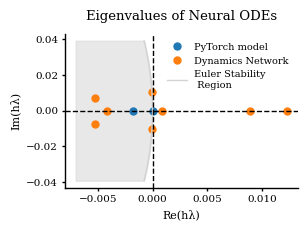

In [26]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, ax = plt.subplots(1,1, figsize=(3,2))
    ax.plot(scaled_eigs_torch.real, scaled_eigs_torch.imag, 'o', label=f"PyTorch model", markersize = 5)
    ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Dynamics Network", markersize = 5)
    theta = np.linspace(-np.pi/80, np.pi/80, 100)
    x = -1 + np.cos(theta)
    y = np.sin(theta)
    x_region = -1 + np.cos(theta)
    y_region = np.sin(theta)

    ax.plot(x, y, color='lightgrey', label='Euler Stability \n Region')
    ax.fill_betweenx(y_region, -0.007, x_region, color='lightgrey', alpha=0.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Re(hλ)', fontsize=8)
    ax.set_ylabel('Im(hλ)', fontsize=8)
    ax.set_title('Eigenvalues of Neural ODEs', pad = 10, fontsize = 9.5)
    ax.legend(fontsize = 7)

    fig.savefig("../svg/eigenvalues.svg", bbox_inches='tight', dpi=300)

In [75]:
from matplotlib.patches import Patch

# Grid in the complex plane
x = np.linspace(-4, 2, 1000)
y = np.linspace(-3, 3, 1000)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

orders = [4, 3, 2, 1]  # RK orders
cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in range(len(orders))]

# Compute stability masks for each order
stability_masks = []
for p in orders:
    S = sum(Z**k / math.factorial(k) for k in range(p+1))
    stable = np.abs(S) <= 1
    stability_masks.append(stable)


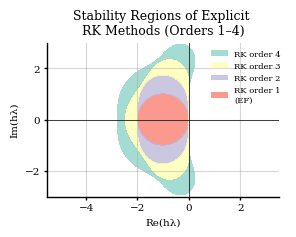

In [ ]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,1, figsize=(3,2))
    fig.subplots_adjust(wspace=0.2)

    mask_cumulative = np.zeros_like(Z, dtype=bool)  # keep track of already filled areas
    for mask, c, p in reversed(list(zip(stability_masks, colors, orders))):
        unique_mask = mask & ~mask_cumulative
        axs.contourf(X, Y, unique_mask, levels=[0.5, 1], colors=[c], alpha = 0.8)
        mask_cumulative |= mask  # update cumulative mask

    axs.axhline(0, color='k', lw=0.5)
    axs.axvline(0, color='k', lw=0.5)
    axs.set_xlabel('Re(hλ)')
    axs.set_ylabel('Im(hλ)')
    axs.set_title('Stability Regions of Explicit \nRK Methods (Orders 1–4)', fontsize = 9)
    axs.grid(True, alpha = 0.5)
    axs.axis('equal')

    # Legend: use the original colors
    legend_elements = [Patch(facecolor=c,  alpha=0.8, label=f'RK order {p}') for c, p in zip(colors, orders)]
    legend_elements[3] = Patch(facecolor=colors[3],  alpha=0.8, label=f'RK order 1 \n(EF)')
    axs.legend(handles=legend_elements, loc='upper right', fontsize = 6, bbox_to_anchor=(1.05, 1.0))

    fig.savefig("../svg/stability_regions.svg", bbox_inches='tight', dpi=300)

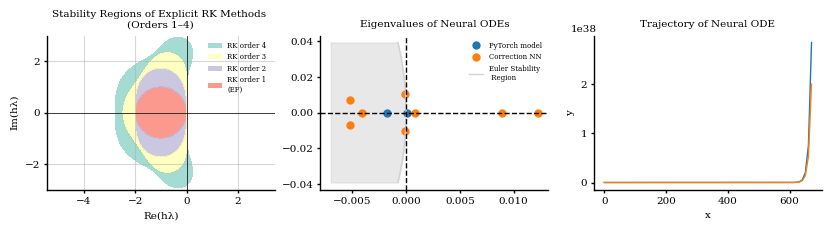

In [ ]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,3, figsize=(10,2))
    fig.subplots_adjust(wspace=0.2)

    mask_cumulative = np.zeros_like(Z, dtype=bool)  # keep track of already filled areas
    for mask, c, p in reversed(list(zip(stability_masks, colors, orders))):
        unique_mask = mask & ~mask_cumulative
        axs[0].contourf(X, Y, unique_mask, levels=[0.5, 1], colors=[c], alpha = 0.8)
        mask_cumulative |= mask  # update cumulative mask

    axs[0].axhline(0, color='k', lw=0.5)
    axs[0].axvline(0, color='k', lw=0.5)
    axs[0].set_xlabel('Re(hλ)')
    axs[0].set_ylabel('Im(hλ)')
    axs[0].set_title('Stability Regions of Explicit RK Methods \n(Orders 1–4)')
    axs[0].grid(True, alpha = 0.5)
    axs[0].axis('equal')

    # Legend: use the original colors
    legend_elements = [Patch(facecolor=c,  alpha=0.8, label=f'RK order {p}') for c, p in zip(colors, orders)]
    legend_elements[3] = Patch(facecolor=colors[3],  alpha=0.8, label=f'RK order 1 \n(EF)')
    axs[0].legend(handles=legend_elements, loc='upper right', fontsize = 5)


    t, y = solve_ode(func) 
    axs[2].plot(t, y[:, 0, 0].detach().numpy()) 
    axs[2].plot(t, y[:, 0, 1].detach().numpy())
    axs[2].yaxis.get_offset_text().set_position((-0.1, 0))   # (x, y) in axis coords
    #axs[0].yaxis.get_offset_text().set_fontsize(5)
    axs[2].set_title('Trajectory of Neural ODE')
    axs[2].set_xlabel('x')
    axs[2].set_ylabel('y')

    axs[1].plot(scaled_eigs_torch.real, scaled_eigs_torch.imag, 'o', label=f"PyTorch model", markersize = 5)
    axs[1].plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Correction NN", markersize = 5)
    theta = np.linspace(-np.pi/80, np.pi/80, 100)
    x = -1 + np.cos(theta)
    y = np.sin(theta)
    x_region = -1 + np.cos(theta)
    y_region = np.sin(theta)

    axs[1].plot(x, y, color='lightgrey', label='Euler Stability \n Region')
    axs[1].fill_betweenx(y_region, -0.007, x_region, color='lightgrey', alpha=0.5)
    axs[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axs[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axs[1].set_title('Eigenvalues of Neural ODEs')
    axs[1].legend(fontsize = 5)

In [7]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.7cm", "5.5cm",
           
    Panel(
          SVG("../svg/stability_regions.svg").scale(svg_scale),
          Text("a", 10.0, 13.5, **kwargs_text),
    ).move(00, 0),
    
    Panel(
          SVG("../svg/eigenvalues.svg").scale(svg_scale),
          Text("b", 10, 8.5, **kwargs_text),
    ).move(258, 5),

    Panel(
          SVG("../svg/trajectory.svg").scale(svg_scale),
          Text("c", 10, 8, **kwargs_text),
    ).move(525, 5),


)

#!mkdir -p fig
f.save("../fig/stability.svg")
svg("../fig/stability.svg")